# Paisabazaar Credit Score Analysis

### Exploratory Data Analysis of Customer Credit Behaviour

Business Domain: Banking & Financial Services
Tools: Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly
Platform: Google Colab

## Business Context

Paisabazaar helps customers compare and apply for financial products.

Creditworthiness is an important factor in:
- Loan approval
- Credit risk assessment
- Financial product recommendations
- Risk management

This project analyzes customer financial behaviour to identify
patterns associated with Good, Standard and Poor credit scores.

## Problem Statement

To analyze customer financial and credit-related behaviour
and identify the factors associated with different credit
score categories.

Target Variable:
Credit_Score

Categories:
- Good
- Standard
- Poor

## Business Questions

1. What is the distribution of customers across credit score categories?
2. How does credit mix relate to credit score?
3. Does payment delay affect credit score?
4. How does outstanding debt differ across credit score categories?
5. Is interest rate associated with credit score?
6. Does credit history age show any relationship with credit score?
7. Which customer behaviours are associated with Poor credit scores?
8. What actionable insights can Paisabazaar derive from the analysis?

## Tools & Libraries


In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

## Load Dataset





In [22]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset (1).csv


In [4]:
df = pd.read_csv("dataset.csv")
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


## Dataset Shape




In [24]:
df.shape

(100000, 28)

## First 5 and Last 5 Records






In [25]:
df.head()


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [8]:
df.tail()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
99995,155625,37932,4,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,34.663572,378.0,No,35.104023,24.028477,High_spent_Large_value_payments,479.866228,Poor
99996,155626,37932,5,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,40.565631,379.0,No,35.104023,24.028477,High_spent_Medium_value_payments,496.651610,Poor
99997,155627,37932,6,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,41.255522,380.0,No,35.104023,24.028477,High_spent_Large_value_payments,516.809083,Poor
99998,155628,37932,7,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,33.638208,381.0,No,35.104023,24.028477,Low_spent_Large_value_payments,319.164979,Standard
99999,155629,37932,8,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,34.192463,382.0,No,35.104023,24.028477,High_spent_Medium_value_payments,393.673696,Poor


## Dataset Information





In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

## Statistical Summary


In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,100000.0,8.063150e+04,4.330149e+04,5634.000000,4.313275e+04,8.063150e+04,1.181302e+05,1.556290e+05
Customer_ID,100000.0,2.598267e+04,1.434054e+04,1006.000000,1.366450e+04,2.577700e+04,3.838500e+04,5.099900e+04
Month,100000.0,4.500000e+00,2.291299e+00,1.000000,2.750000e+00,4.500000e+00,6.250000e+00,8.000000e+00
Age,100000.0,3.331634e+01,1.076481e+01,14.000000,2.400000e+01,3.300000e+01,4.200000e+01,5.600000e+01
SSN,100000.0,5.004617e+08,2.908267e+08,81349.000000,2.451686e+08,5.006886e+08,7.560027e+08,9.999934e+08
Annual_Income,100000.0,5.050512e+04,3.829942e+04,7005.930000,1.934297e+04,3.699971e+04,7.168347e+04,1.799873e+05
Monthly_Inhand_Salary,100000.0,4.197271e+03,3.186432e+03,303.645417,1.626594e+03,3.095905e+03,5.957715e+03,1.520463e+04
Num_Bank_Accounts,100000.0,5.368820e+00,2.593314e+00,0.000000,3.000000e+00,5.000000e+00,7.000000e+00,1.100000e+01
Num_Credit_Card,100000.0,5.533570e+00,2.067098e+00,0.000000,4.000000e+00,5.000000e+00,7.000000e+00,1.100000e+01
Interest_Rate,100000.0,1.453208e+01,8.741330e+00,1.000000,7.000000e+00,1.300000e+01,2.000000e+01,3.400000e+01


## Check Missing Values






In [30]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0


## Check Duplicate Records




In [74]:
df.duplicated().sum()

np.int64(0)

## Customer ID Analysis






In [75]:
df['Customer_ID'].nunique()

12500

In [76]:
df['Month'].value_counts().sort_index()

,count
Month,
1,12500
2,12500
3,12500
4,12500
5,12500
6,12500
7,12500
8,12500


## Check Target Variable





In [77]:
df['Credit_Score'].value_counts()

,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


In [78]:
df['Credit_Score'].value_counts(normalize=True) * 100

,proportion
Credit_Score,
Standard,53.174
Poor,28.998
Good,17.828


## Visualization — Credit Score Distribution




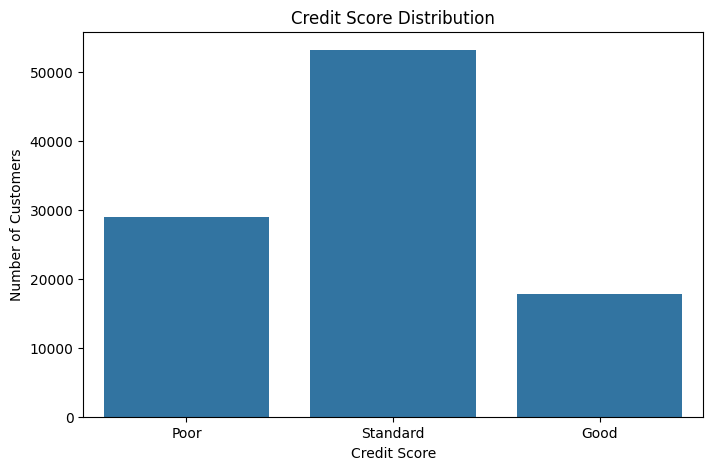

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Credit_Score',
    order=['Poor', 'Standard', 'Good']
)

plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')

plt.show()

## Univariate Analysis







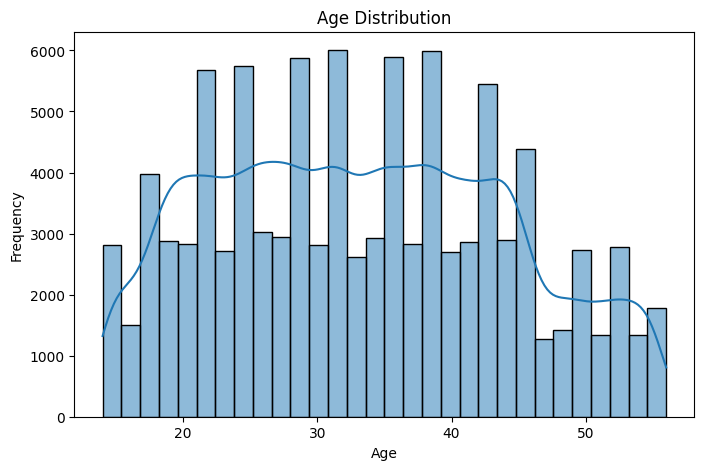

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='Age', bins=30, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

## Annual Income Distribution




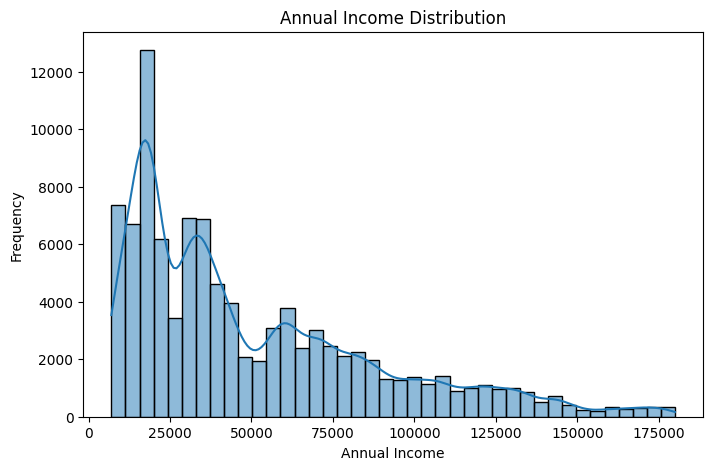

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Annual_Income',
    bins=40,
    kde=True
)

plt.title('Annual Income Distribution')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')

plt.show()

## Outstanding Debt Distribution





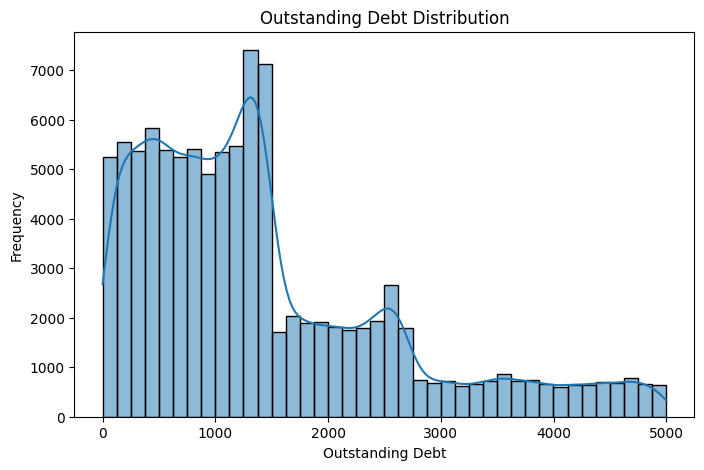

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Outstanding_Debt',
    bins=40,
    kde=True
)

plt.title('Outstanding Debt Distribution')
plt.xlabel('Outstanding Debt')
plt.ylabel('Frequency')

plt.show()

## Categorical Analysis






In [41]:
df['Credit_Mix'].value_counts()

,count
Credit_Mix,
Standard,45848
Good,30384
Bad,23768


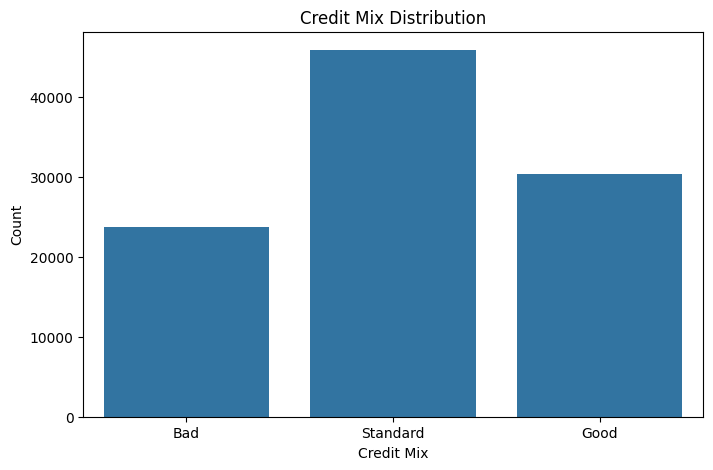

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Credit_Mix',
    order=['Bad', 'Standard', 'Good']
)

plt.title('Credit Mix Distribution')
plt.xlabel('Credit Mix')
plt.ylabel('Count')

plt.show()

### Bivariate Analysis






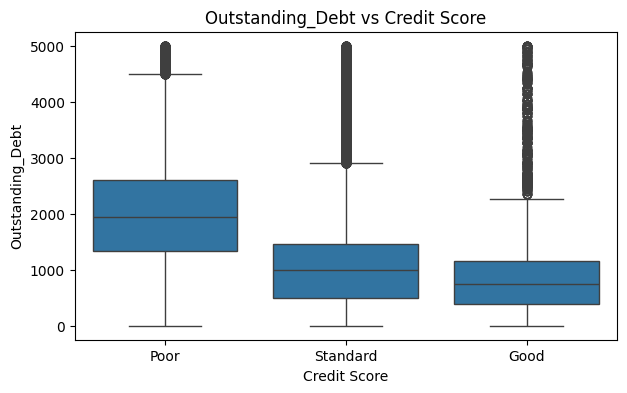

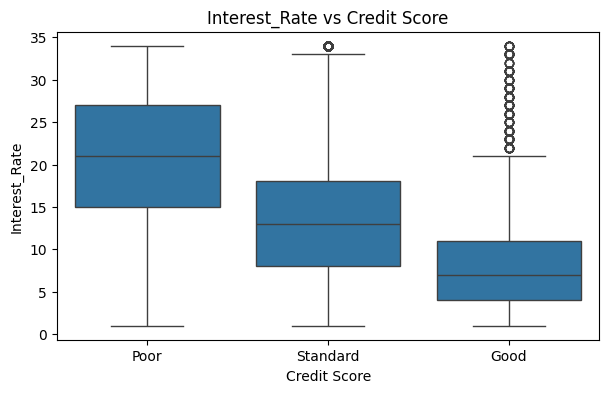

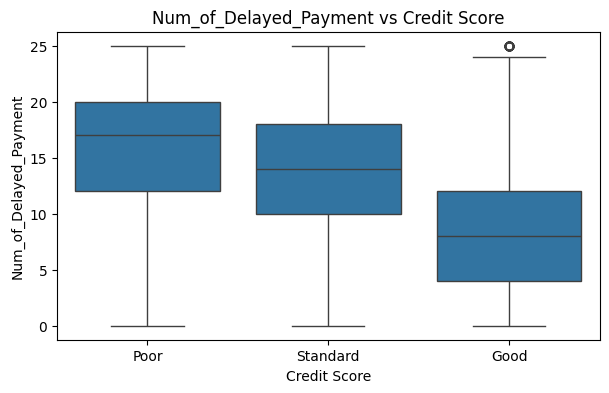

In [79]:
features = [
    'Outstanding_Debt',
    'Interest_Rate',
    'Num_of_Delayed_Payment'
]

for feature in features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x='Credit_Score', y=feature,
                order=['Poor', 'Standard', 'Good'])
    plt.title(f'{feature} vs Credit Score')
    plt.xlabel('Credit Score')
    plt.ylabel(feature)
    plt.show()

## Credit Mix vs Credit Score






In [45]:
credit_mix_score = pd.crosstab(
    df['Credit_Mix'],
    df['Credit_Score'],
    normalize='index'
) * 100

credit_mix_score

Credit_Score,Good,Poor,Standard
Credit_Mix,,,
Bad,1.476775,60.118647,38.404578
Good,48.867825,15.965640,35.166535
Standard,5.734165,21.501483,72.764352


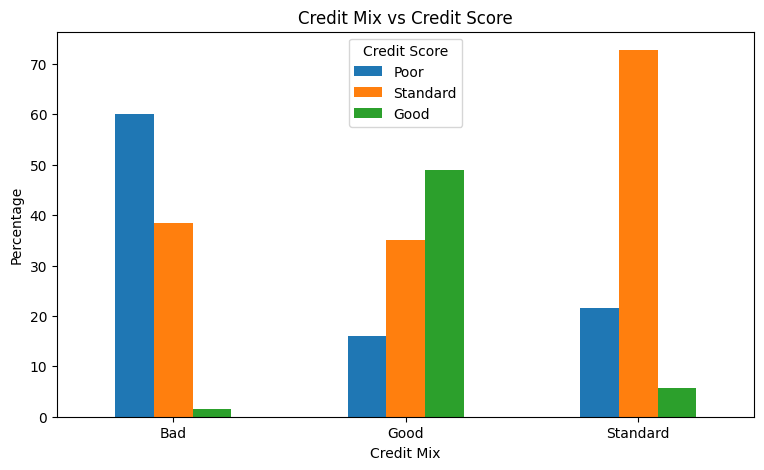

In [46]:
credit_mix_score[
    ['Poor', 'Standard', 'Good']
].plot(
    kind='bar',
    figsize=(9,5)
)

plt.title('Credit Mix vs Credit Score')
plt.xlabel('Credit Mix')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Credit Score')

plt.show()

## Delayed Payment vs Credit Score








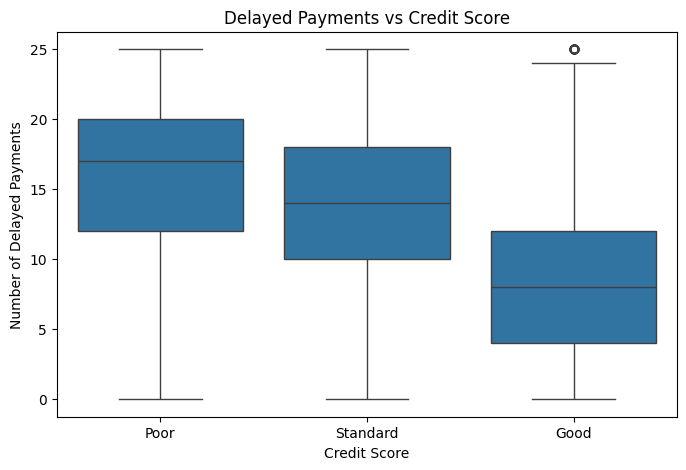

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Credit_Score',
    y='Num_of_Delayed_Payment',
    order=['Poor', 'Standard', 'Good']
)

plt.title('Delayed Payments vs Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Number of Delayed Payments')

plt.show()

In [48]:
df.groupby('Credit_Score')['Num_of_Delayed_Payment'].mean().round(2)

,Num_of_Delayed_Payment
Credit_Score,
Good,8.56
Poor,15.81
Standard,13.54


## Delay From Due Date vs Credit Score





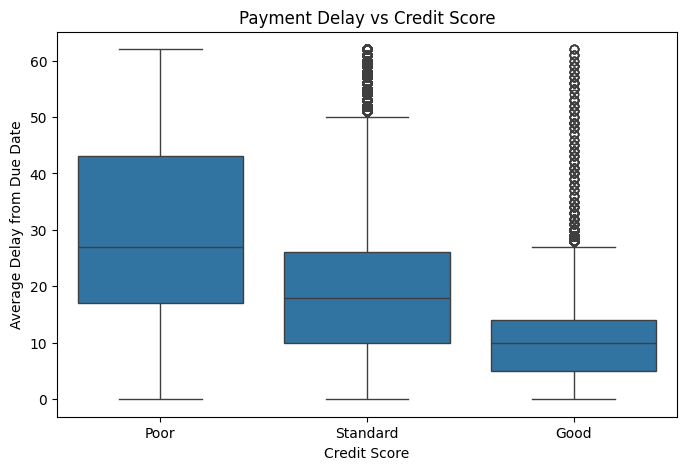

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Credit_Score',
    y='Delay_from_due_date',
    order=['Poor', 'Standard', 'Good']
)

plt.title('Payment Delay vs Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Average Delay from Due Date')

plt.show()

In [50]:
df.groupby('Credit_Score')['Delay_from_due_date'].mean().round(2)

,Delay_from_due_date
Credit_Score,
Good,10.96
Poor,29.73
Standard,19.76


## Outstanding Debt vs Credit Score





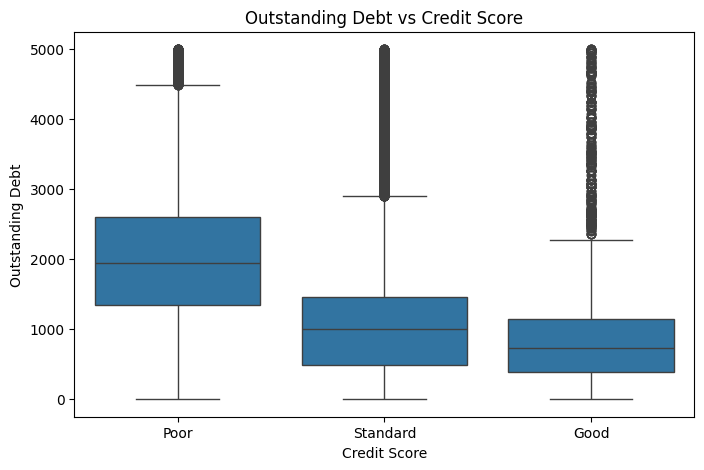

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Credit_Score',
    y='Outstanding_Debt',
    order=['Poor', 'Standard', 'Good']
)

plt.title('Outstanding Debt vs Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Outstanding Debt')

plt.show()

In [52]:
df.groupby('Credit_Score')['Outstanding_Debt'].mean().round(2)

,Outstanding_Debt
Credit_Score,
Good,801.26
Poor,2081.47
Standard,1278.42


## Interest Rate vs Credit Score








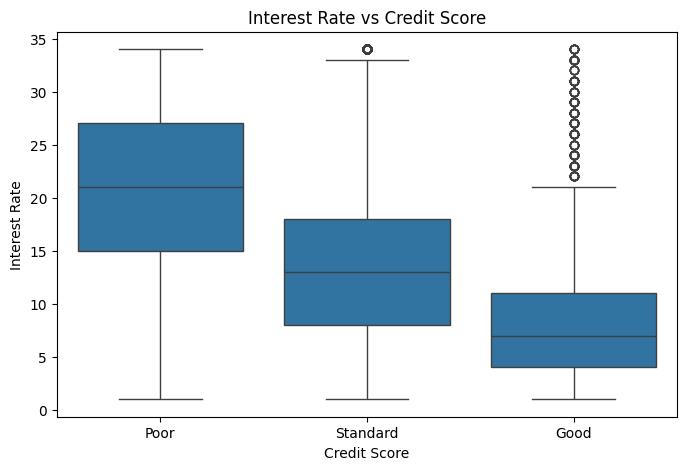

In [54]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Credit_Score',
    y='Interest_Rate',
    order=['Poor', 'Standard', 'Good']
)

plt.title('Interest Rate vs Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Interest Rate')

plt.show()

In [53]:
df.groupby('Credit_Score')['Interest_Rate'].mean().round(2)

,Interest_Rate
Credit_Score,
Good,7.66
Poor,20.19
Standard,13.75


## Credit History Age vs Credit Score





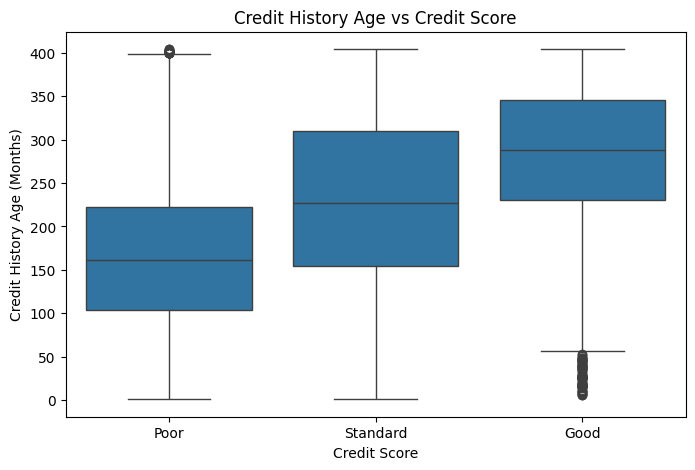

In [55]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Credit_Score',
    y='Credit_History_Age',
    order=['Poor', 'Standard', 'Good']
)

plt.title('Credit History Age vs Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Credit History Age (Months)')

plt.show()

In [56]:
df.groupby('Credit_Score')['Credit_History_Age'].mean().round(2)

,Credit_History_Age
Credit_Score,
Good,284.77
Poor,170.06
Standard,227.81


## Num Credit Inquiries vs Credit Score






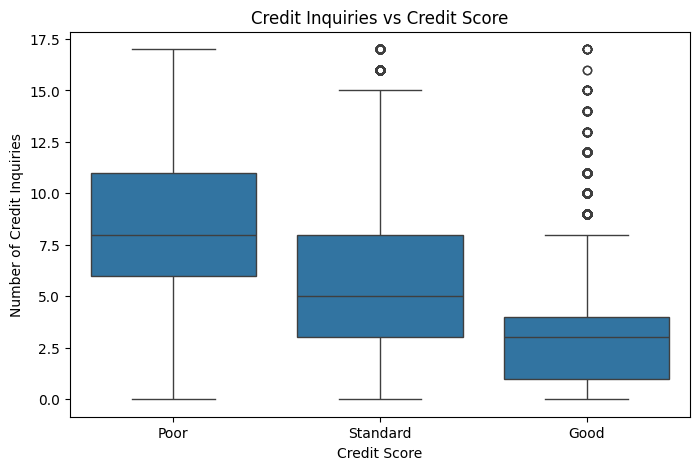

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Credit_Score',
    y='Num_Credit_Inquiries',
    order=['Poor', 'Standard', 'Good']
)

plt.title('Credit Inquiries vs Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Number of Credit Inquiries')

plt.show()

In [58]:
df.groupby('Credit_Score')['Num_Credit_Inquiries'].mean().round(2)

,Num_Credit_Inquiries
Credit_Score,
Good,3.30
Poor,8.18
Standard,5.34


## Payment Behaviour vs Credit Score

Code:

Visualization:





In [59]:
payment_score = pd.crosstab(
    df['Payment_Behaviour'],
    df['Credit_Score'],
    normalize='index'
) * 100

payment_score.round(2)

Credit_Score,Good,Poor,Standard
Payment_Behaviour,,,
High_spent_Large_value_payments,23.39,21.49,55.12
High_spent_Medium_value_payments,20.03,25.70,54.27
High_spent_Small_value_payments,18.59,27.33,54.08
Low_spent_Large_value_payments,18.03,28.14,53.83
Low_spent_Medium_value_payments,18.04,30.17,51.79
Low_spent_Small_value_payments,12.95,35.56,51.50


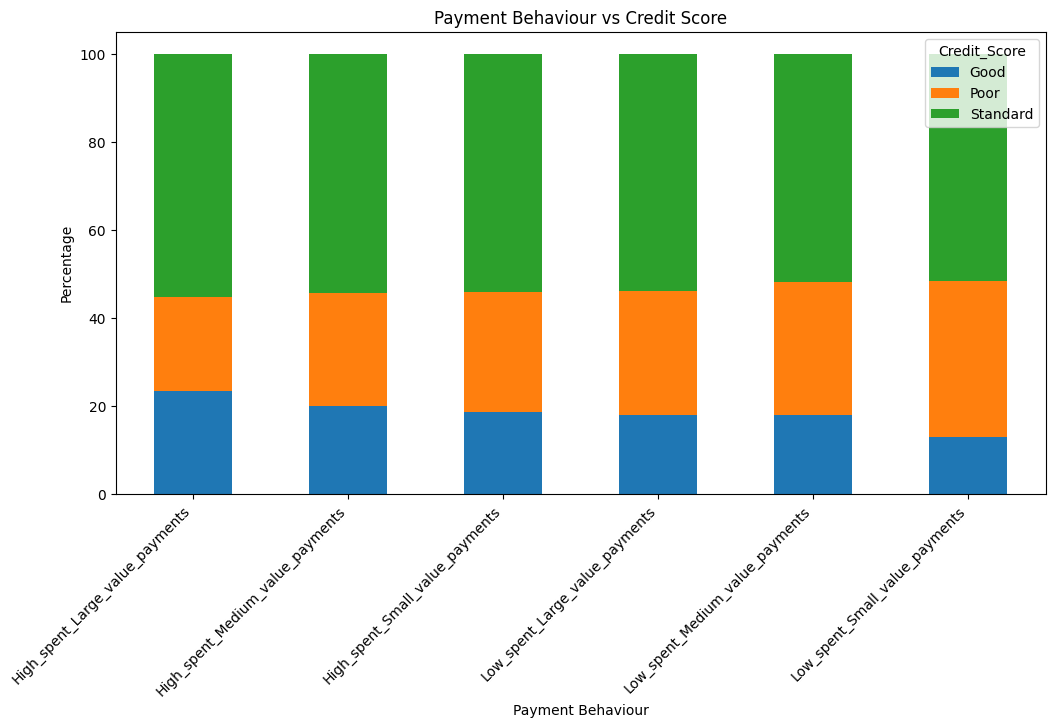

In [60]:
payment_score.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Payment Behaviour vs Credit Score')
plt.xlabel('Payment Behaviour')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')

plt.show()

## Multivariate Analysis





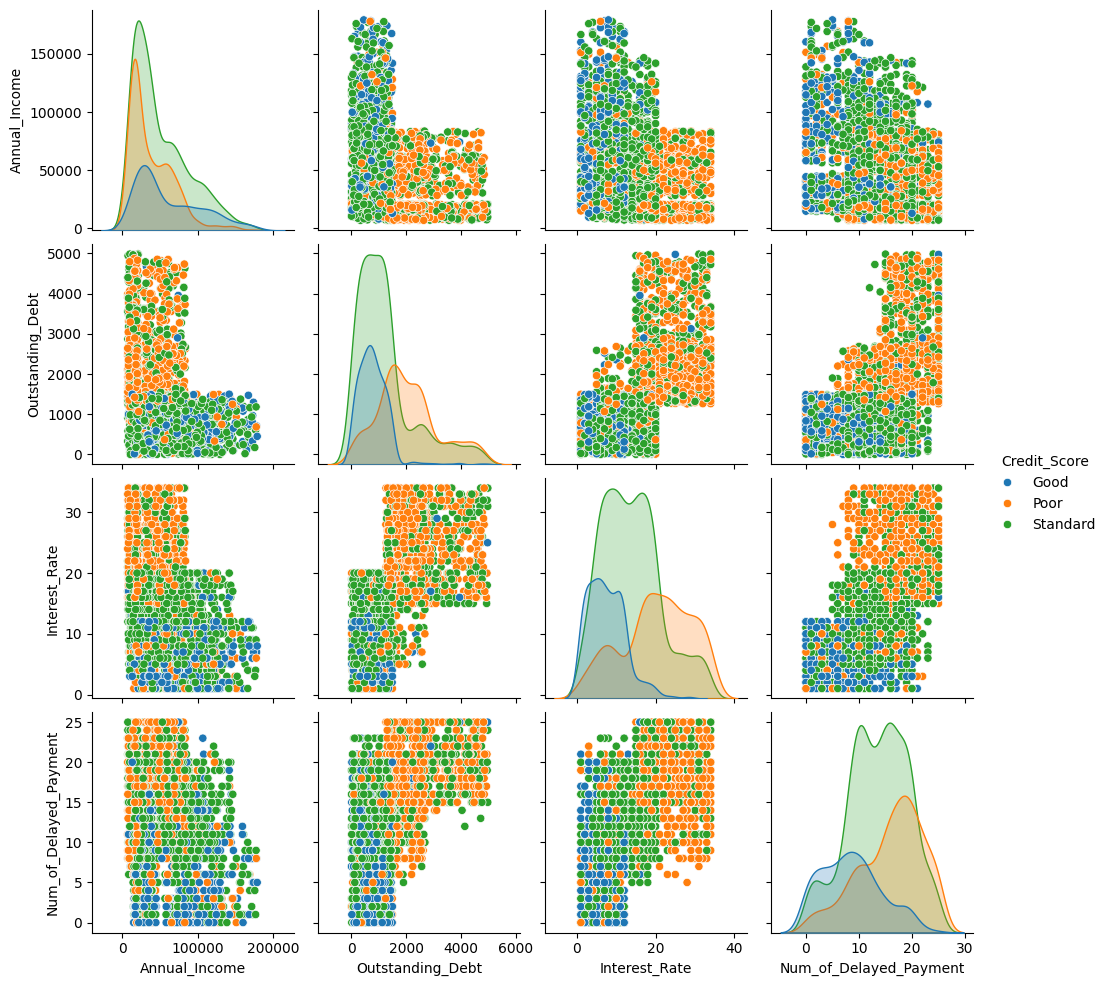

In [70]:
sample_df = df.sample(3000, random_state=42)

sns.pairplot(
    sample_df[['Annual_Income',
               'Outstanding_Debt',
               'Interest_Rate',
               'Num_of_Delayed_Payment',
               'Credit_Score']],
    hue='Credit_Score'
)

plt.show()

## Correlation Heatmap





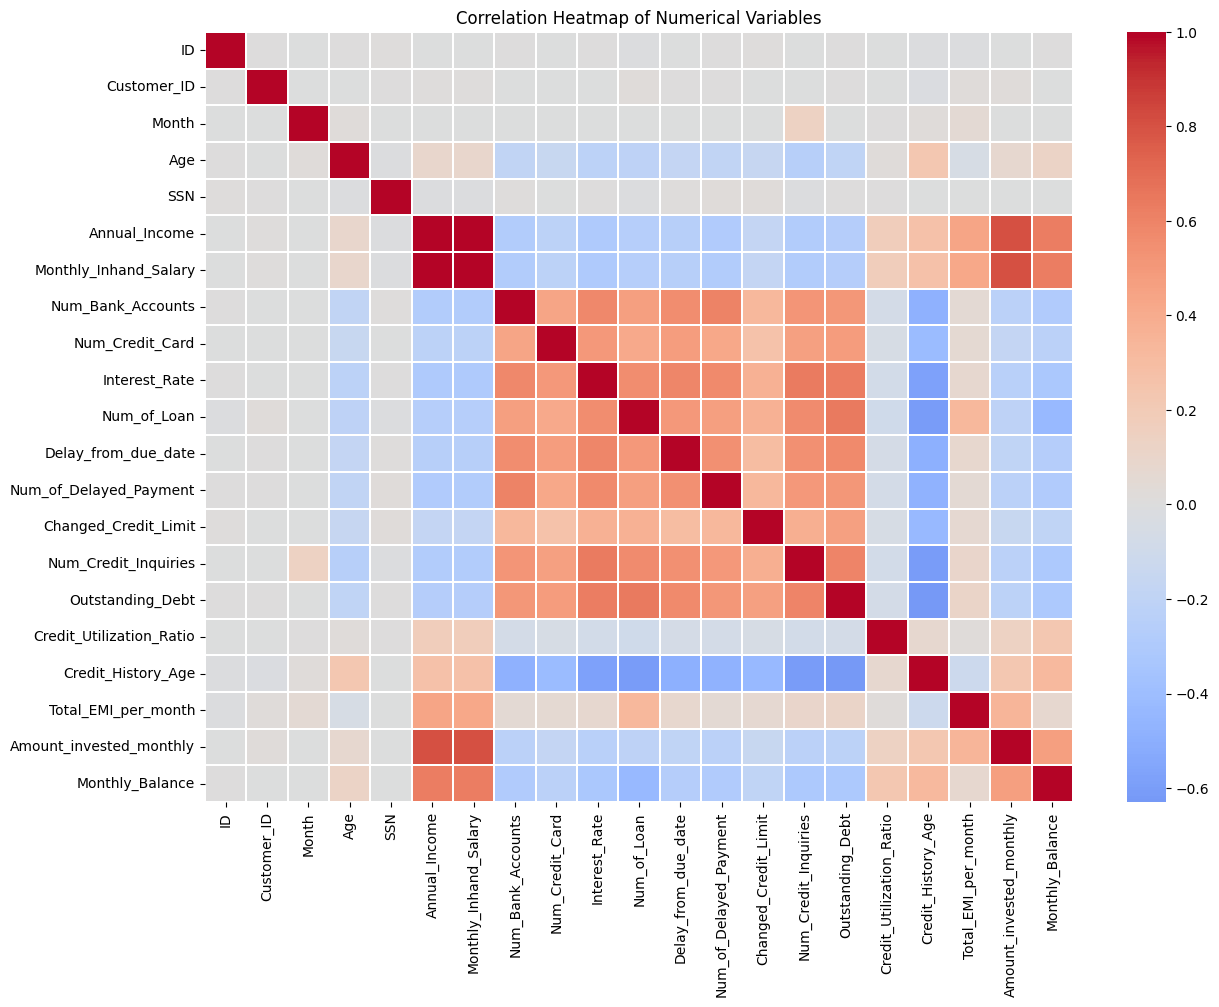

In [68]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(14,10))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    linewidths=0.3
)

plt.title('Correlation Heatmap of Numerical Variables')

plt.show()

## Multivariate Business View





In [71]:
summary = df.groupby('Credit_Score')[
    [
        'Annual_Income',
        'Outstanding_Debt',
        'Interest_Rate',
        'Delay_from_due_date',
        'Num_of_Delayed_Payment',
        'Num_Credit_Inquiries',
        'Credit_History_Age'
    ]
].mean().round(2)

summary

,Annual_Income,Outstanding_Debt,Interest_Rate,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Credit_History_Age
Credit_Score,,,,,,,
Good,65203.67,801.26,7.66,10.96,8.56,3.30,284.77
Poor,40584.52,2081.47,20.19,29.73,15.81,8.18,170.06
Standard,50987.16,1278.42,13.75,19.76,13.54,5.34,227.81


## Outlier Analysis






In [72]:
num_cols = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append(
        [col, count, round(count / len(df) * 100, 2)]
    )

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=['Column', 'Outlier_Count', 'Outlier_Percentage']
)

outlier_df.sort_values(
    'Outlier_Count',
    ascending=False
)

,Column,Outlier_Count,Outlier_Percentage
20,Monthly_Balance,7400,7.40
15,Outstanding_Debt,5272,5.27
18,Total_EMI_per_month,5044,5.04
19,Amount_invested_monthly,4464,4.46
11,Delay_from_due_date,4002,4.00
6,Monthly_Inhand_Salary,2017,2.02
5,Annual_Income,2000,2.00
14,Num_Credit_Inquiries,787,0.79
13,Changed_Credit_Limit,579,0.58
16,Credit_Utilization_Ratio,4,0.00


## Why We Don't Remove Every Outlier

## Outlier Treatment Strategy

- Identify outliers using IQR.
- Check whether extreme values are realistic.
- Avoid blindly deleting financial observations.
- Preserve legitimate customer behaviour.
- For future ML modelling, consider:
    - Capping/Winsorization
    - Robust scaling
    - Log transformation
    - Model-based treatment

## Plotly Interactive Visualization




In [73]:
fig = px.box(
    df,
    x='Credit_Score',
    y='Outstanding_Debt',
    color='Credit_Score',
    category_orders={
        'Credit_Score': ['Poor', 'Standard', 'Good']
    },
    title='Outstanding Debt Across Credit Score Categories'
)

fig.show()

## Key Findings

A final Markdown section.

1. Standard credit score is the largest category.
2. Credit Mix shows a strong association with Credit Score.
3. Poor credit score customers have significantly more payment delays.
4. Poor credit score customers have substantially higher outstanding debt.
5. Poor credit score customers have higher average interest rates.
6. Poor credit score customers have more credit inquiries.
7. Good credit score customers have longer credit histories.
8. Multiple financial factors together provide stronger risk signals.

## Business Recommendations

Recommendation 1 — Payment Risk Monitoring

Customers showing frequent delayed payments can be flagged for additional credit-risk assessment.

Recommendation 2 — Debt Management

Customers with high outstanding debt can be identified for financial guidance or suitable debt-management products.

Recommendation 3 — Credit Mix

Credit Mix can be incorporated as one of the factors in customer segmentation and credit-risk assessment.

Recommendation 4 — Customer Segmentation

Customers can be segmented into Good, Standard and Poor risk groups and offered more relevant financial products.

Recommendation 5 — Early Warning System

Customers showing multiple risk signals—such as high debt, frequent delays and high credit inquiries—can be monitored through an early-warning system.

Recommendation 6 — Personalized Financial Advice

Customers with weaker credit behaviour can be provided with educational recommendations related to timely payments, debt management and responsible credit usage.

## Challenges Faced

- Large dataset with 100,000 records
- Repeated Customer IDs due to monthly observations
- Potential outliers in financial variables
- Different numerical and categorical variables
- Imbalanced target variable
- Selecting meaningful visualizations
- Converting statistical findings into business insights



## Notebook Quality / Testing

```
# Final dataset shape
print("Dataset Shape:", df.shape)

# Missing values
print("Total Missing Values:", df.isnull().sum().sum())

# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Unique customers
print("Unique Customers:", df['Customer_ID'].nunique())

# Target categories
print("Credit Score Categories:",
      df['Credit_Score'].unique())
```



## Final Conclusion

# Conclusion

- Credit score is associated with several customer financial behaviours.
- Payment delays show a strong relationship with Poor credit scores.
- Higher outstanding debt is associated with poorer credit scores.
- Credit Mix is an important differentiating factor.
- Poor credit score customers show higher average interest rates and credit inquiries.
- Longer credit history is associated with better credit scores.
- Combining multiple variables provides a better understanding of credit risk.

## Future Scope

1. Feature Engineering
2. Machine Learning Classification
3. Feature Importance Analysis
4. Model Evaluation
5. Explainable AI
6. Interactive Dashboard
7. Customer Risk Segmentation